
## Clasificación de Sentimientos de Reseñas de Películas en IMDb con Redes Neuronales Recurrentes


Se requiere realizar un modelo Deep Learning usando redes neuronales recurrentes RNN, para análisis de sentimientos en reseñas de películas de la plataforma web IMBD clasificándolas como positivas o negativas.

Para lograr este modelo se realizarán los siguientes pasos:

1. Importar las librerías necesarias.
2. Realizar extracción de los datos y analisis descriptivo.
3. Realizar embedding por medio de la librería Word2Vec.
4. Partición del dataset en entrenamiento, validación y prueba
5. Definición de hiperparámetros para la RNN
6. Búsqueda aleatoria de mejores hiperparámetros
7. Análisis de resultados.

In [80]:
! pip install keras_tuner
! pip install gensim
! pip install nltk
! pip install kagglehub
! pip install visualkeras


[notice] A new release of pip is available: 23.3.2 -> 25.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 23.3.2 -> 25.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 23.3.2 -> 25.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 23.3.2 -> 25.0.1
[notice] To update, run: python -m pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 992.0/992.0 kB 97.6 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.3.2 -> 25.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [81]:
import kagglehub

import pandas as pd
import numpy as np
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from gensim.models import Word2Vec

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Embedding, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import visualkeras
import keras_tuner as kt

In [61]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [49]:
np.random.seed(42)
tf.random.set_seed(42)

In [50]:
# Descargar última versión del dataset con la API de Kaggle
data_dir = kagglehub.dataset_download("yasserh/imdb-movie-ratings-sentiment-analysis")

print("Path to dataset files:", data_dir)
data_dir

Path to dataset files: /root/.cache/kagglehub/datasets/yasserh/imdb-movie-ratings-sentiment-analysis/versions/1


'/root/.cache/kagglehub/datasets/yasserh/imdb-movie-ratings-sentiment-analysis/versions/1'

In [51]:
file_path = os.path.join(data_dir, "movie.csv")
df = pd.read_csv(file_path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    40000 non-null  object
 1   label   40000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 625.1+ KB


In [52]:
df.describe()

,label
count,40000.000000
mean,0.499525
std,0.500006
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [53]:
print(df['label'].value_counts())

0    20019
1    19981
Name: label, dtype: int64


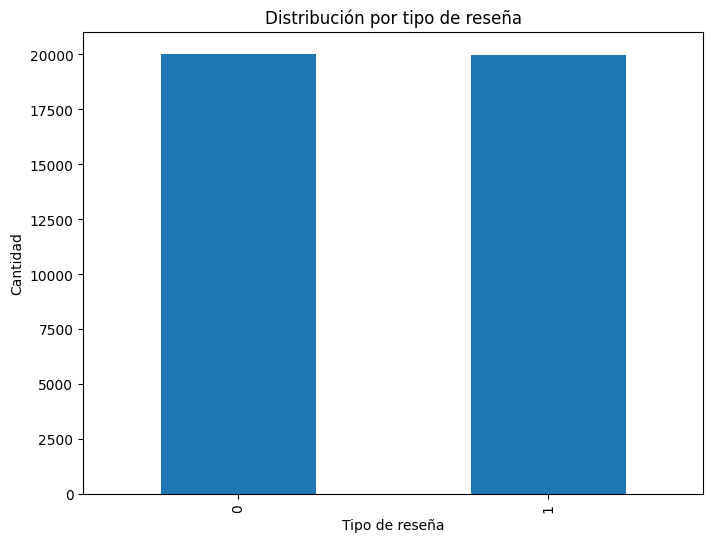

In [54]:
# Plot sentiment distribution
plt.figure(figsize=(8, 6))
df['label'].value_counts().plot(kind='bar')
plt.title('Distribución por tipo de reseña')
plt.ylabel('Cantidad')
plt.xlabel('Tipo de reseña')
plt.show()

count    40000.000000
mean       231.339250
std        171.194123
min          4.000000
25%        126.000000
50%        173.000000
75%        282.000000
max       2470.000000
Name: review_length, dtype: float64


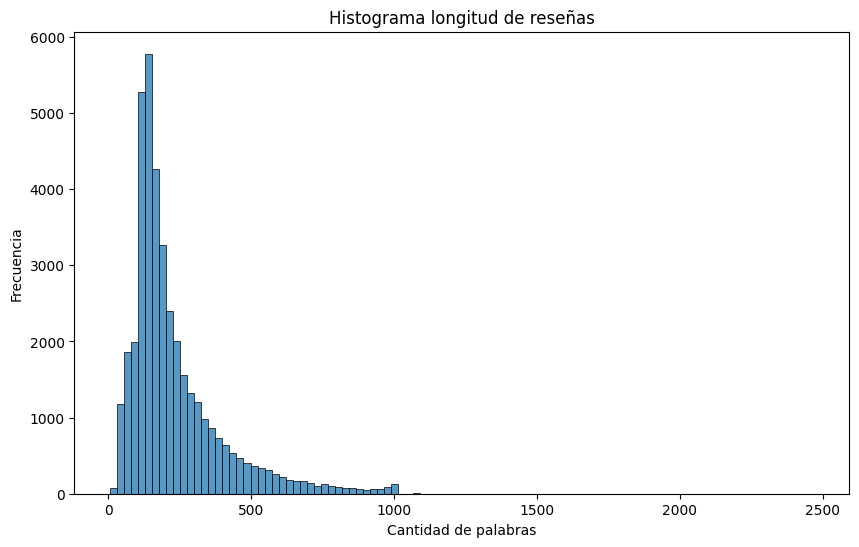

In [55]:
df['review_length'] = df['text'].apply(lambda x: len(str(x).split()))

print(df['review_length'].describe())

# Plot review length distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['review_length'], bins=100)
plt.title('Histograma longitud de reseñas')
plt.ylabel('Frecuencia')
plt.xlabel('Cantidad de palabras')
plt.show()

In [56]:
def preprocess_text(text):
    """
    Limpia y preprocesa texto para usar con Word2Vec.

    Args:
        text (str): Texto crudo, como una reseña de película.

    Returns:
        list: Lista de palabras tokenizadas y preprocesadas.
    """
    # Manejar valores nulos
    if pd.isna(text):
        return []

    # Convertir a minúsculas
    text = text.lower()

    # Eliminar etiquetas HTML
    text = re.sub(r'<.*?>', '', text)

    # Eliminar URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Eliminar números y caracteres especiales, pero mantener apóstrofes para contracciones
    text = re.sub(r'[^a-zA-Z\']', ' ', text)

    # Reemplazar contracciones comunes en inglés por sus formas completas
    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"can't", "cannot", text)
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'re", " are", text)
    text = re.sub(r"'s", " is", text)
    text = re.sub(r"'d", " would", text)
    text = re.sub(r"'ll", " will", text)
    text = re.sub(r"'ve", " have", text)
    text = re.sub(r"'m", " am", text)

    # Reemplazar múltiples espacios por un solo espacio
    text = re.sub(r'\s+', ' ', text)

    # Tokenizar el texto en palabras individuales
    tokens = word_tokenize(text)

    # Eliminar palabras vacías (stopwords)
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]

    # Lematizar las palabras (reducir a su forma base)
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Eliminar palabras de un solo carácter y cadenas vacías
    tokens = [word for word in tokens if len(word) > 1]

    return tokens

In [65]:
def preprocess_reviews(df, column_name='text'):


    # Reseña sin procesar
    print("\nReseña sin procesar")
    print(df['text'].iloc[0])
    
    # Aplica el preprocesamiento a todas las reseñas
    df['processed_review'] = df['text'].apply(preprocess_text)
    
    # Reseña procesada
    print("\nReseña procesada")
    print(df['processed_review'].iloc[0])
    
    return df

In [64]:
 df = preprocess_reviews(df)


Reseña sin procesar
I grew up (b. 1965) watching and loving the Thunderbirds. All my mates at school watched. We played "Thunderbirds" before school, during lunch and after school. We all wanted to be Virgil or Scott. No one wanted to be Alan. Counting down from 5 became an art form. I took my children to see the movie hoping they would get a glimpse of what I loved as a child. How bitterly disappointing. The only high point was the snappy theme tune. Not that it could compare with the original score of the Thunderbirds. Thankfully early Saturday mornings one television channel still plays reruns of the series Gerry Anderson and his wife created. Jonatha Frakes should hand in his directors chair, his version was completely hopeless. A waste of film. Utter rubbish. A CGI remake may be acceptable but replacing marionettes with Homo sapiens subsp. sapiens was a huge error of judgment.

Reseña procesada
['grew', 'watching', 'loving', 'thunderbird', 'mate', 'school', 'watched', 'played', '

In [66]:
def train_word2vec_model(processed_reviews, vector_size=100, window=5, min_count=5, workers=4):
    """
    Entrena un modelo Word2Vec con las reseñas preprocesadas.
    
    Args:
        processed_reviews (list): Lista de reseñas, cada una representada como lista de palabras (tokens).
        vector_size (int): Tamaño del vector que representará cada palabra.
        window (int): Tamaño de la ventana de contexto (número de palabras a izquierda y derecha).
        min_count (int): Frecuencia mínima para que una palabra sea incluida en el vocabulario.
        workers (int): Número de hilos para el entrenamiento en paralelo.
    
    Returns:
        model (Word2Vec): Modelo Word2Vec entrenado.
    """
    print("\nPASO 3: Entrenando el modelo Word2Vec...")

    # Entrena el modelo Word2Vec usando el algoritmo Skip-gram (sg=1)
    model = Word2Vec(
        sentences=processed_reviews,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        workers=workers,
        sg=1  # sg=1 usa el modelo Skip-gram (mejor para vocabulario más pequeño o más preciso)
    )
    
    return model

In [67]:
word2vec_model = train_word2vec_model(df['processed_review'].tolist())


PASO 3: Entrenando el modelo Word2Vec...
Modelo Word2Vec entrenado con un vocabulario de tamaño: 31946
Modelo Word2Vec guardado como 'imdb_word2vec.model'

Palabras similares a 'excellent':
superb: 0.8856
outstanding: 0.8566
fantastic: 0.8479
terrific: 0.8467
wonderful: 0.8341


In [70]:
def prepare_data_for_rnn(df, word2vec_model, max_sequence_length=150):
    """
    Prepara los datos para el modelo RNN utilizando embeddings de Word2Vec.
    
    Args:
        df (DataFrame): Conjunto de datos con las reseñas procesadas y las etiquetas.
        word2vec_model (Word2Vec): Modelo Word2Vec previamente entrenado.
        max_sequence_length (int): Longitud máxima de las secuencias (número de palabras por reseña).
    
    Returns:
        Tupla con los datos divididos: X_train, X_val, X_test, y_train, y_val, y_test,
        y los vectores de palabras del modelo Word2Vec.
    """
    print("\nPASO 4: Preparando los datos para el modelo RNN...")

    # Convertir el texto en secuencias de índices de palabras según el modelo Word2Vec
    sequences = []
    for review in df['processed_review']:
        seq = []
        for word in review[:max_sequence_length]:  # Limita la longitud de la reseña
            if word in word2vec_model.wv:
                # Usa el índice de la palabra en el vocabulario del modelo
                seq.append(word2vec_model.wv.key_to_index[word])
            else:
                # Usa 0 si la palabra no está en el vocabulario (fuera de vocabulario)
                seq.append(0)
        sequences.append(seq)
    
    # Rellenar (pad) las secuencias para que todas tengan la misma longitud
    padded_sequences = pad_sequences(sequences, maxlen=max_sequence_length, padding='post')
    print(f"Secuencias rellenadas a longitud fija: {max_sequence_length}")
    
    # Separar las etiquetas y las entradas
    X = padded_sequences
    y = df['label'].values

    # Primera división: 80% entrenamiento + validación, 20% prueba
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Segunda división: del conjunto de entrenamiento+validación, separamos 25% para validación
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
    )
    
    # Mostrar tamaños de cada conjunto
    print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras")
    print(f"Conjunto de validación: {X_val.shape[0]} muestras")
    print(f"Conjunto de prueba: {X_test.shape[0]} muestras")
    
    # Devuelve los conjuntos listos y los vectores de palabras del modelo
    return X_train, X_val, X_test, y_train, y_val, y_test, word2vec_model.wv.vectors

In [71]:
X_train, X_val, X_test, y_train, y_val, y_test, embedding_matrix = prepare_data_for_rnn(df, word2vec_model)


PASO 4: Preparando los datos para el modelo RNN...
Secuencias rellenadas a longitud fija: 150
Conjunto de entrenamiento: 24000 muestras
Conjunto de validación: 8000 muestras
Conjunto de prueba: 8000 muestras


In [74]:
def build_model_for_tuner(hp, embedding_matrix, vocab_size, max_sequence_length=150):
    """
    Construye un modelo de red neuronal para ser ajustado con Keras Tuner.

    Args:
        hp: Objeto de hiperparámetros de Keras Tuner.
        embedding_matrix (np.array): Matriz de embeddings preentrenada (Word2Vec).
        vocab_size (int): Tamaño del vocabulario.
        max_sequence_length (int): Longitud máxima de las secuencias de entrada.
    
    Returns:
        model (Sequential): Modelo de Keras construido con los hiperparámetros dados.
    """
    model = Sequential()

    # Capa de embedding con pesos preentrenados (no entrenable)
    embedding_dim = embedding_matrix.shape[1]
    model.add(Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_sequence_length,
        trainable=False
    ))

    # Ajuste de arquitectura LSTM
    # Número de capas LSTM a usar (entre 1 y 3)
    lstm_layers = hp.Int('lstm_layers', min_value=1, max_value=3, step=1)

    for i in range(lstm_layers):
        # Número de unidades en cada capa LSTM
        lstm_units = hp.Int(f'lstm_units_{i}', min_value=32, max_value=256, step=32)

        # Si se usa una LSTM bidireccional o no
        if hp.Boolean(f'bidirectional_{i}'):
            model.add(Bidirectional(LSTM(
                lstm_units,
                return_sequences=(i < lstm_layers - 1)  # Solo devolver secuencias si no es la última capa
            )))
        else:
            model.add(LSTM(
                lstm_units,
                return_sequences=(i < lstm_layers - 1)
            ))

        # Dropout después de cada capa LSTM
        dropout_rate = hp.Float(f'dropout_{i}', min_value=0.0, max_value=0.5, step=0.1)
        model.add(Dropout(dropout_rate))

    # Capas densas (fully connected) adicionales
    dense_layers = hp.Int('dense_layers', min_value=1, max_value=3, step=1)

    for i in range(dense_layers):
        dense_units = hp.Int(f'dense_units_{i}', min_value=16, max_value=256, step=16)
        model.add(Dense(dense_units, activation='relu'))

        # Dropout después de cada capa densa
        dropout_rate = hp.Float(f'dense_dropout_{i}', min_value=0.0, max_value=0.5, step=0.1)
        model.add(Dropout(dropout_rate))

    # Capa de salida (clasificación binaria con sigmoide)
    model.add(Dense(1, activation='sigmoid'))

    # Compilación del modelo
    # Tasa de aprendizaje a ajustar (entre 0.0001 y 0.01 en escala logarítmica)
    learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')

    # Elección del optimizador (Adam o RMSprop)
    optimizer_choice = hp.Choice('optimizer', values=['adam', 'rmsprop'])

    if optimizer_choice == 'adam':
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    else:
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [78]:
def tune_hyperparameters(X_train, y_train, X_val, y_val, embedding_matrix, vocab_size, max_sequence_length=150):
    """
    Usa Keras Tuner (RandomSearch) para encontrar los mejores hiperparámetros del modelo

    Args:
        X_train (np.array): Datos de entrenamiento (secuencias).
        y_train (np.array): Etiquetas de entrenamiento.
        X_val (np.array): Datos de validación.
        y_val (np.array): Etiquetas de validación.
        embedding_matrix (np.array): Matriz de embeddings preentrenados.
        vocab_size (int): Tamaño del vocabulario.
        max_sequence_length (int): Longitud máxima de las secuencias.

    Returns:
        best_model (tf.keras.Model): Modelo con la mejor combinación de hiperparámetros.
        best_hps (HyperParameters): Objeto con los hiperparámetros óptimos.
    """
    print("\nPASO 6: Realizando ajuste de hiperparámetros (RandomSearch)...")

    def model_builder(hp):
        return build_model_for_tuner(hp, embedding_matrix, vocab_size, max_sequence_length)

    # Inicializa el tuner con RandomSearch
    tuner = kt.RandomSearch(
        model_builder,
        objective='val_accuracy',
        max_trials=10,  # Máximo de 10 combinaciones de hiperparámetros a evaluar
        directory='keras_tuner',
        project_name='imdb_sentiment_randomsearch'
    )

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

    print("Resumen del espacio de búsqueda:")
    tuner.search_space_summary()

    print("\nIniciando búsqueda de hiperparámetros...")
    tuner.search(
        X_train, y_train,
        epochs=15,
        validation_data=(X_val, y_val),
        callbacks=[early_stopping],
        verbose=1
    )

    best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

    print("\nMejores hiperparámetros encontrados:")
    for param in best_hps.values:
        print(f"{param}: {best_hps.get(param)}")

    best_model = tuner.hypermodel.build(best_hps)

    print("\nArquitectura del mejor modelo:")
    best_model.summary()

    with open('best_hyperparameters.txt', 'w') as f:
        for param in best_hps.values:
            f.write(f"{param}: {best_hps.get(param)}\n")

    return best_model, best_hps

In [79]:
vocab_size = len(word2vec_model.wv.index_to_key) #+ 1  # +1 for out-of-vocabulary words
best_model, best_hps = tune_hyperparameters(X_train, y_train, X_val, y_val, embedding_matrix, vocab_size)

Trial 10 Complete [00h 04m 41s]
val_accuracy: 0.8817499876022339

Best val_accuracy So Far: 0.8846250176429749
Total elapsed time: 00h 28m 50s

Mejores hiperparámetros encontrados:
lstm_layers: 1
lstm_units_0: 64
bidirectional_0: False
dropout_0: 0.0
dense_layers: 1
dense_units_0: 112
dense_dropout_0: 0.0
learning_rate: 0.001097447399464499
optimizer: rmsprop
lstm_units_1: 256
bidirectional_1: False
dropout_1: 0.30000000000000004
lstm_units_2: 128
bidirectional_2: True
dropout_2: 0.4

Arquitectura del mejor modelo:
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 150, 100)          3194600   
                                                                 
 lstm_3 (LSTM)               (None, 64)                42240     
                                                                 
 dropout_4 (Dropout)         (None, 64)                0     

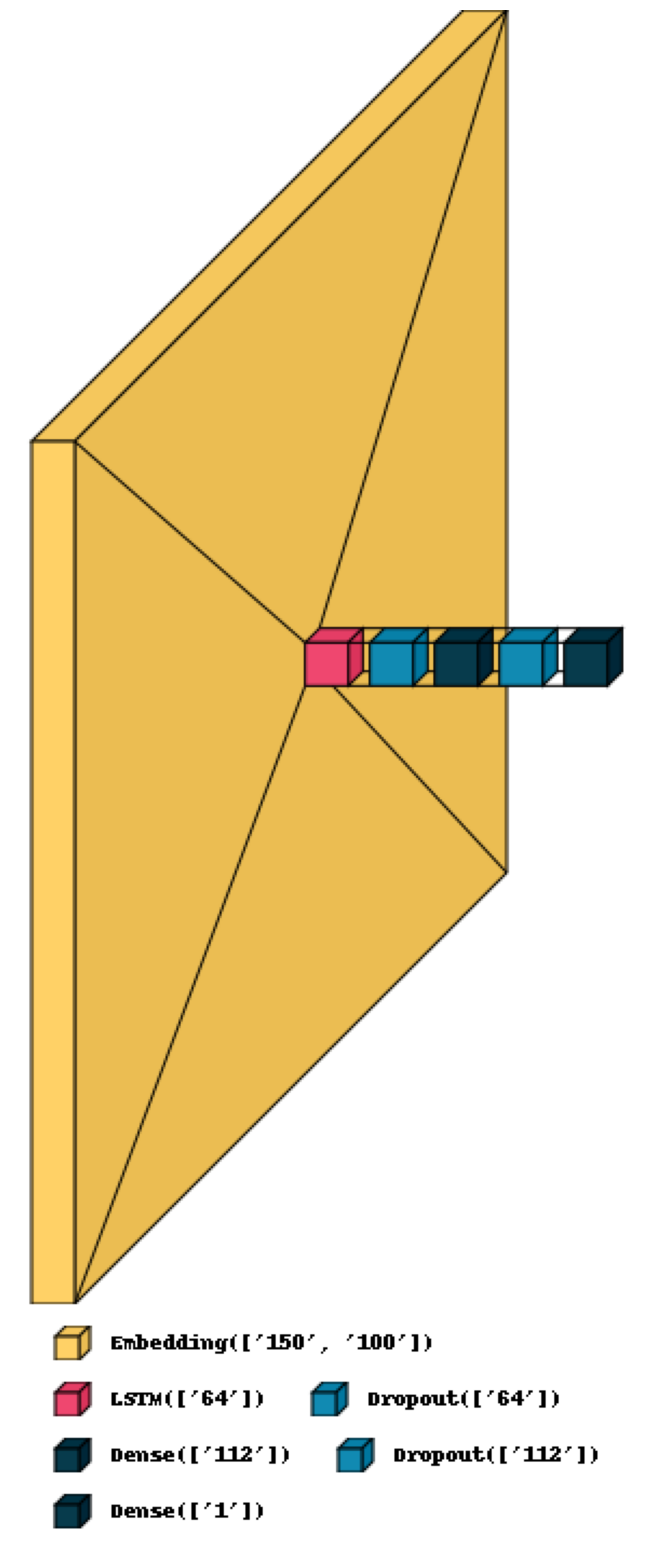

In [82]:
img = visualkeras.layered_view(best_model, legend=True, show_dimension=True)

plt.figure(figsize=(20, 20))
plt.imshow(img)
plt.axis('off')
plt.show()

In [85]:
def train_best_model(model, X_train, y_train, X_val, y_val, batch_size=64, epochs=20):
    """
    Entrena el mejor modelo encontrado durante el ajuste de hiperparámetros.
    """
    print("\nPASO 7: Entrenando el mejor modelo...")

    # Define la estrategia de detención temprana para evitar sobreajuste
    early_stopping = EarlyStopping(
        monitor='val_loss',          # Se monitorea la pérdida en validación
        patience=5,                  # Se detiene si no mejora en 5 épocas consecutivas
        restore_best_weights=True   # Restaura los mejores pesos al final del entrenamiento
    )

    # Define un checkpoint para guardar el mejor modelo basado en la precisión de validación
    checkpoint = ModelCheckpoint(
        'best_tuned_model.h5',      # Ruta del archivo donde se guarda el modelo
        monitor='val_accuracy',     # Se guarda el modelo que tenga mejor precisión en validación
        save_best_only=True,        # Solo guarda si es el mejor
        verbose=1                   # Muestra información durante el guardado
    )

    # Entrena el modelo con los datos de entrenamiento y validación
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),  # Conjunto de validación
        epochs=epochs,                   # Número total de épocas
        batch_size=batch_size,           # Tamaño del batch
        callbacks=[early_stopping, checkpoint],  # Callbacks para controlar el entrenamiento
        verbose=1                        # Nivel de verbosidad
    )

    # Grafica el historial de entrenamiento

    plt.figure(figsize=(12, 5))

    # Precisión del modelo
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])         # Precisión en entrenamiento
    plt.plot(history.history['val_accuracy'])     # Precisión en validación
    plt.title('Precisión del Modelo')
    plt.ylabel('Precisión')
    plt.xlabel('Época')
    plt.legend(['Entrenamiento', 'Validación'], loc='lower right')

    # Pérdida del modelo
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])             # Pérdida en entrenamiento
    plt.plot(history.history['val_loss'])         # Pérdida en validación
    plt.title('Pérdida del Modelo')
    plt.ylabel('Pérdida')
    plt.xlabel('Época')
    plt.legend(['Entrenamiento', 'Validación'], loc='upper right')

    plt.tight_layout()
    plt.savefig('tuned_model_training_history.png')  # Guarda la figura como imagen
    plt.show()

    return model, history  # Retorna el modelo entrenado y su historial


PASO 7: Entrenando el mejor modelo...
Epoch 1/20
371/375 [============================>.] - ETA: 0s - loss: 0.2842 - accuracy: 0.8836
Epoch 1: val_accuracy improved from -inf to 0.87725, saving model to best_tuned_model.h5
375/375 [==============================] - 3s 9ms/step - loss: 0.2844 - accuracy: 0.8834 - val_loss: 0.3010 - val_accuracy: 0.8773
Epoch 2/20
371/375 [============================>.] - ETA: 0s - loss: 0.2764 - accuracy: 0.8862
Epoch 2: val_accuracy did not improve from 0.87725
375/375 [==============================] - 3s 8ms/step - loss: 0.2766 - accuracy: 0.8863 - val_loss: 0.2953 - val_accuracy: 0.8771
Epoch 3/20
375/375 [==============================] - ETA: 0s - loss: 0.2698 - accuracy: 0.8890
Epoch 3: val_accuracy did not improve from 0.87725
375/375 [==============================] - 3s 9ms/step - loss: 0.2698 - accuracy: 0.8890 - val_loss: 0.2977 - val_accuracy: 0.8761
Epoch 4/20
374/375 [============================>.] - ETA: 0s - loss: 0.2625 - accuracy: 

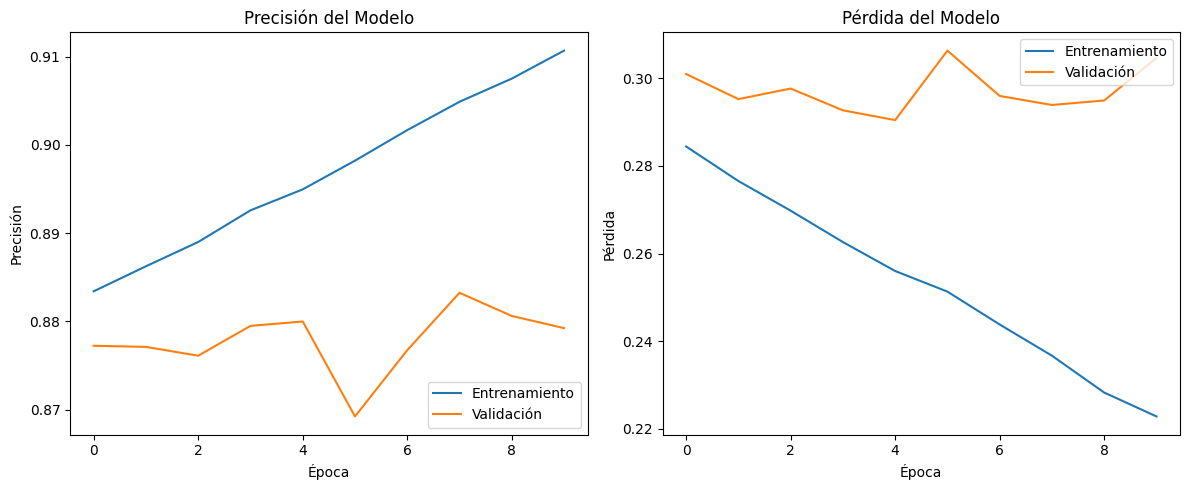

In [86]:
best_model, history = train_best_model(best_model, X_train, y_train, X_val, y_val)

In [89]:
def evaluate_best_model(model, X_test, y_test):
    """
    Evaluate the best model on the test set and generate a classification report
    """
    print("\nSTEP 8: Evaluating the best model...")
    
    # Evaluate the model on the test set
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    
    # Get predictions
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()
    
    # Generate classification report
    print("\nClassification Report:")
    report = classification_report(y_test, y_pred)
    print(report)
    

    
    # Generate confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig('tuned_model_confusion_matrix.png')
    plt.show()
    
    # Calculate additional metrics
    true_positives = conf_matrix[1, 1]
    false_positives = conf_matrix[0, 1]
    true_negatives = conf_matrix[0, 0]
    false_negatives = conf_matrix[1, 0]
    
    precision = true_positives / (true_positives + false_positives)
    recall = true_positives / (true_positives + false_negatives)
    f1_score = 2 * (precision * recall) / (precision + recall)
    
    print(f"\nAdditional Metrics:")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1_score:.4f}")
    
    return report, conf_matrix


STEP 8: Evaluating the best model...
Test Loss: 0.2914
Test Accuracy: 0.8814

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88      4004
           1       0.87      0.89      0.88      3996

    accuracy                           0.88      8000
   macro avg       0.88      0.88      0.88      8000
weighted avg       0.88      0.88      0.88      8000



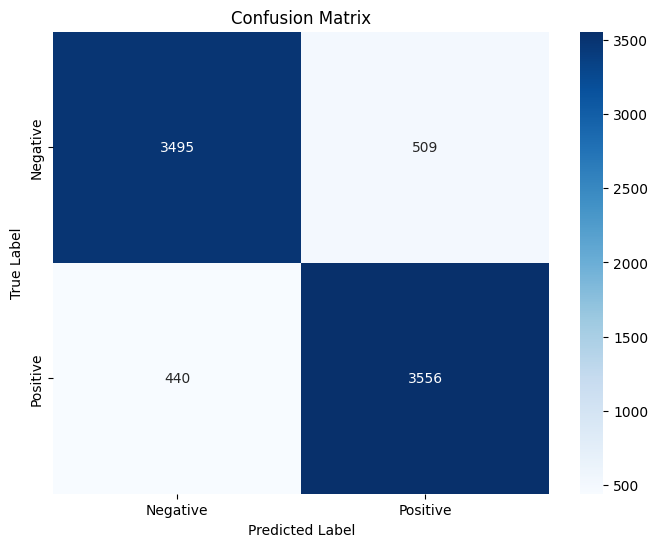


Additional Metrics:
Precision: 0.8748
Recall: 0.8899
F1-Score: 0.8823


In [90]:
report, conf_matrix = evaluate_best_model(best_model, X_test, y_test)